# Pipeline klasyfikacji obrazów

Zbiór to zdjęcia śmieci z przypisanymi etykietami:
- cardboard
- glass
- metal
- paper
- plastic
- trash

## Preprocessing
Za nim co kolwiek zrobimy z danymi, powinniśmy na nie spojrzeć.

In [50]:
import pandas as pd
import sklearn
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import seaborn as sns
import matplotlib.pyplot as plt
import PIL

In [51]:
raw_df = pd.read_csv('./train/_classes.csv')
raw_df.head()

,filename,cardboard,glass,metal,paper,plastic,trash
0,paper59_jpg.rf.wzR5NbRz2yDZECnFaw2m.jpg,0,0,0,1,0,0
1,plastic34_jpg.rf.wzyVtvyXtoYA45vl2U7m.jpg,0,0,0,0,1,0
2,glass131_jpg.rf.xKSWDJgXD3JxEOJrObp4.jpg,0,1,0,0,0,0
3,metal155_jpg.rf.xZPyMvYIV6SuhJdqYibK.jpg,0,0,1,0,0,0
4,metal53_jpg.rf.xvclQIoWptlLu6TuixHa.jpg,0,0,1,0,0,0


2524
filename     0
cardboard    0
glass        0
metal        0
paper        0
plastic      0
trash        0
dtype: int64


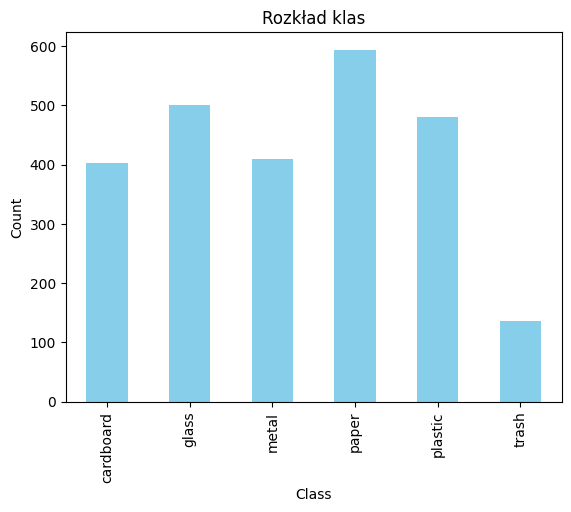

In [52]:
class_counts = raw_df.drop('filename', axis=1).sum()
print(class_counts.sum())
print(raw_df.isnull().sum()) 
class_counts.plot(kind='bar', color='skyblue', )
plt.xlabel('Class')
plt.ylabel('Count')
plt.title('Rozkład klas')
plt.show()

Nie ma pustych wartości, liczba klas jest równa liczbie zdjęć, więc nie ma sytuacji gdzie zdjęcie nie ma przypisanej klasy lub jest przypisane do kilku klas


In [53]:
class_names = raw_df.columns[1:]

file_names = raw_df['filename'].values
labels = raw_df[class_names].values

In [54]:
batch_size = 32

#prawdziwe wartości
# img_height = 384
# img_width = 512

#skalowane wartości
img_height = 128
img_width = 128


In [55]:
data_dir = './train/' 

# Generalnie tutaj przesunąłem każde zdjęcie do swojego folderu (nazwa folderu = klasa)
# po użyciu keras.utils.image_dataset_from_directory etykiety zamieniły się na liczby zamiast OH encoded
# dlaczego?:
# https://stackoverflow.com/questions/63906723/keras-image-dataset-from-directory-not-finding-images

train_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "training",
    image_size=(img_height,img_width),
    seed=67,
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split = 0.2,
    subset = "validation",
    image_size=(img_height,img_width),
    seed=67,
    batch_size=batch_size
)

class_name = train_ds.class_names
num_classes = len(class_name)

Found 2524 files belonging to 6 classes.
Using 2020 files for training.
Found 2524 files belonging to 6 classes.
Using 504 files for validation.


In [56]:
# KRÓTKA OPTYMALIZACJA
# https://www.tensorflow.org/tutorials/images/classification#:~:text=Dataset%2Ecache,training,-%2E

AUTOTUNE = tf.data.AUTOTUNE
                                                    
train_ds = train_ds.shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Flatten, add, Dense, Dropout, Rescaling,BatchNormalization, Conv2D, MaxPool2D, GlobalAveragePooling2D
from tensorflow.keras.callbacks import EarlyStopping

data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal",
                      input_shape=(img_height,
                                  img_width,
                                  3)),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
    layers.RandomBrightness(0.1)
  ]
)


model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255, input_shape=(img_height, img_width,3)),

    layers.Conv2D(32, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(64, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, 3, padding='same'),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.MaxPooling2D(),

    layers.GlobalAveragePooling2D(),

    layers.Dense(64),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(0.5),
    
    layers.Dense(num_classes)
])

model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

model.summary()

EarlyStop = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

history = model.fit(train_ds, validation_data=val_ds, epochs=40, callbacks=[EarlyStop])

/home/ukasz/Desktop/projekt_smieci/.venv/lib/python3.11/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_6 (Sequential)       │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_5 (Rescaling)         │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 128, 128, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_16 (Conv2D)              │ (None, 64, 64, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_16 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_17 (Conv2D)              │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_17 (MaxPooling2D) │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_5      │ (None, 64)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 28,134 (109.90 KB)

 Trainable params: 28,134 (109.90 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 55s 671ms/step - accuracy: 0.2277 - loss: 1.7257 - val_accuracy: 0.3115 - val_loss: 1.6518
Epoch 2/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 45s 666ms/step - accuracy: 0.3475 - loss: 1.5953 - val_accuracy: 0.3234 - val_loss: 1.5205
Epoch 3/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 661ms/step - accuracy: 0.3931 - loss: 1.4957 - val_accuracy: 0.4603 - val_loss: 1.3973
Epoch 4/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 44s 656ms/step - accuracy: 0.4045 - loss: 1.4238 - val_accuracy: 0.4683 - val_loss: 1.3100
Epoch 5/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 47s 715ms/step - accuracy: 0.4569 - loss: 1.3457 - val_accuracy: 0.4821 - val_loss: 1.2485
Epoch 6/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 51s 769ms/step - accuracy: 0.4743 - loss: 1.3110 - val_accuracy: 0.4940 - val_loss: 1.2256
Epoch 7/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 710ms/step - accuracy: 0.4950 - loss: 1.2589 - val_accuracy: 0.4940 - val_loss: 1.2711
Epoch 8/40
64/64 ━━━━━━━━━━━━━━━━━━━━ 48s 716ms/step - accuracy: 0.5045 - loss: 1.2385 - val_accu

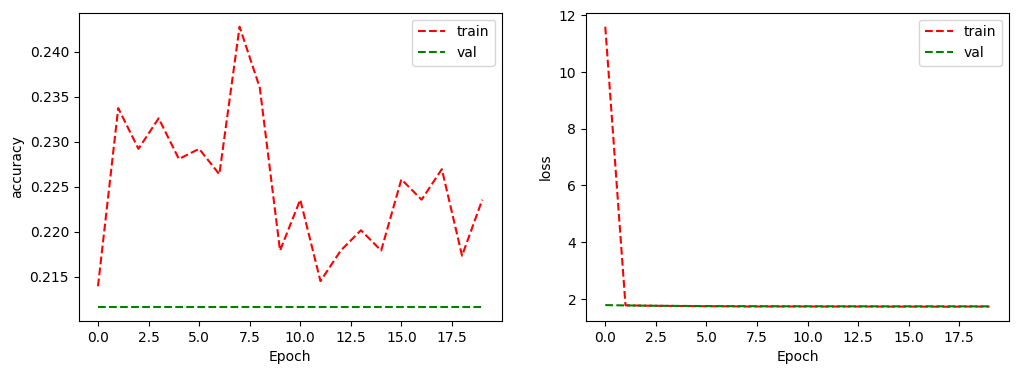

In [ ]:
def draw_curves(history):
    plt.figure(figsize=(12,4))
    
    plt.subplot(1, 2, 1)
    plt.plot(history.history['accuracy'], "r--", label='train')
    plt.plot(history.history['val_accuracy'], "g--", label='val')
    plt.ylabel('accuracy')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(history.history['loss'], "r--", label='train')
    plt.plot(history.history['val_loss'], "g--", label='val')
    plt.ylabel('loss')
    plt.xlabel('Epoch')
    plt.legend()
    
    plt.show()

draw_curves(history)